# Modelling — Leuven ↔ Brussels Commuter Delays (Checkpoint)

**Business goal:** warn Leuven↔Brussels commuters that their train is going to be delayed, roughly one hour ahead of time.

**Where we left off.** Feature Engineering gave us three ready-to-use tables, one row per train run reaching Leuven with a real upstream corridor stop to learn from: `train` (Jan–Apr, 18,666 rows), `val` (May, 4,665 rows), `test` (Jun–Jul, 10,094 rows). The target is `delay_arr_min`(minutes late arriving at Leuven) and the standout feature is `last_stop_delay_min`, the delay already observed at the most recent upstream corridor stop.

One caveat worth restating up front: that last upstream stop sits only ~9 minutes before Leuven's scheduled arrival on average (median 8 minutes), not a full hour. So while the business framing is "warn commuters an hour ahead", what we can actually build here predicts from whatever lead time `scheduled_minutes_since_last_stop` gives for a given run that is usually well under 60 minutes with data scoped to these 6 stations. We flag this again at the end for Stage 5.

This is CRISP-DM step 4: **Modelling**, and we do it deliberately out of order compared to what feels natural:
1. Build a few genuinely *naive* baselines and measure them properly, before touching a real model.
2. Pick a metric that means something to a non-technical stakeholder.
3. Take exactly **one** modest step up from the best baseline, this is not a tuning marathon!

In [1]:
import os

# make "../../data/..." paths resolve whether Jupyter was launched from the repo root or from notebooks/
if not os.path.isdir("../../data") and os.path.isdir("data"):
    os.chdir("notebooks/assignment_notebooks")

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor

%matplotlib inline

TRAIN_PATH = "../../data/checkpoints/train.parquet"
VAL_PATH = "../../data/checkpoints/val.parquet"
TEST_PATH = "../../data/checkpoints/test.parquet"
PREDICTIONS_PATH = "../../data/checkpoints/model_predictions.csv"

ID_COLS = ["TRAIN_NO", "service_date", "RELATION"]
TARGET_COL = "delay_arr_min"

train = pd.read_parquet(TRAIN_PATH)
val = pd.read_parquet(VAL_PATH)
test = pd.read_parquet(TEST_PATH)
train.shape, val.shape, test.shape


((18666, 20), (4665, 20), (10094, 20))

## 🤔 What would a good baseline model be in this case?

Before reaching for any model, it's worth asking what a *no-model* prediction would look like, a real model only earns its complexity if it clears that bar by more than noise. Three genuinely naive candidates, roughly from silliest to smartest:

- **Predict zero.** Assume every train is exactly on time. Naive, but it's literally the promise the timetable makes. Worth knowing how wrong that assumption already is.
- **Predict the training set's mean/median delay**, ignoring everything about the specific run. Still a single constant number, but at least it's *the right constant* on average.
- **Persistence: predict `last_stop_delay_min` unchanged.** Assume whatever delay we already observed at the last corridor stop simply carries through to Leuven with no further change. This is the first baseline that uses any run-specific information at all, and given how strong delay propagation looked in Data Understanding, it's the one we expect to be hardest to beat.

## 🤔 How will we measure performance?

Both MAE and RMSE are reasonable choices for a numeric target like this, but they answer slightly different questions:

- **MAE (mean absolute error)** is the average number of minutes we're off by, full stop. It's directly the sentence you'd say to a commuter: *"on average, our warning is off by about X minutes."* Every minute of error counts the same, regardless of size.
- **RMSE** squares errors before averaging, which makes it more sensitive to the rare huge miss (e.g. a 40-minute disruption). That's a legitimate thing to care about operationally, but it's a worse number to put in front of a non-technical stakeholder! "our RMSE is 3.4" doesn't mean anything to a commuter, and it doesn't correspond to any single train's experience the way MAE does.

We use **MAE as the headline metric** here because it matches the business framing directly, and report RMSE alongside it as a secondary check on whether a model is getting hurt by a handful of large misses.

In [3]:
def score(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
    }


## 🔧 Train some baselines — who can get the best baseline that is still a baseline?

We score all three candidates on **both** `val` and `test` whereas `test` matters most, since it's the split that most resembles genuinely future data the "model" has never touched (val was used for none of these, but keeping the habit pays off once we get to a real ML model below).

In [4]:
train_mean = train[TARGET_COL].mean()
train_median = train[TARGET_COL].median()

def predict_zero(df):
    return np.zeros(len(df))

def predict_train_mean(df):
    return np.full(len(df), train_mean)

def predict_train_median(df):
    return np.full(len(df), train_median)

def predict_persistence(df):
    return df["last_stop_delay_min"].to_numpy()

BASELINES = {
    "predict_zero": predict_zero,
    "predict_train_mean": predict_train_mean,
    "predict_train_median": predict_train_median,
    "persistence": predict_persistence,
}

baseline_rows = []
for name, predict_fn in BASELINES.items():
    for split_name, split in [("val", val), ("test", test)]:
        baseline_rows.append({"model": name, "split": split_name, **score(split[TARGET_COL], predict_fn(split))})

baseline_results = pd.DataFrame(baseline_rows)
baseline_results.pivot(index="model", columns="split", values=["MAE", "RMSE"]).round(3)


MAE          RMSE       
split                  test    val   test    val
model                                           
persistence           0.919  1.291  1.827  3.386
predict_train_mean    3.469  3.719  6.989  7.940
predict_train_median  3.014  3.537  7.270  8.330
predict_zero          3.104  3.725  7.465  8.548

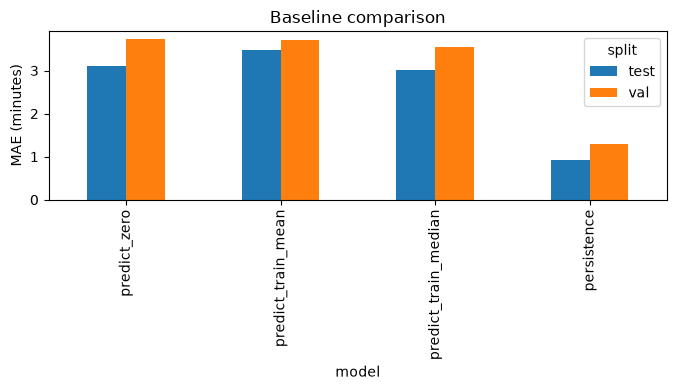

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
baseline_results.pivot(index="model", columns="split", values="MAE").loc[list(BASELINES)].plot.bar(ax=ax)
ax.set_ylabel("MAE (minutes)")
ax.set_title("Baseline comparison")
plt.tight_layout()


**Persistence wins clearly**, on both metrics and both splits, by a wide margin over predicting zero or a constant mean/median. That matches Data Understanding's finding that delay propagation is strong: knowing the delay 6-10 minutes upstream already gets most of the way to Leuven's actual delay. Interestingly, "predict zero" edges out the train-mean/median baselines on `test`. The test months (Jun-Jul) apparently ran a little more on-time on average than the training months, which is exactly the kind of thing a single global constant can't adapt to.

**Persistence is our baseline to beat.**

## 🔧 Try to beat your baseline (once, modestly, not a tuning marathon)

One modest step up: a single `GradientBoostingRegressor`, left at (almost) default hyperparameters, fed the full leakage-safe feature set from Feature Engineering. Categorical columns get one-hot encoded; everything else passes through unchanged. No hyperparameter search, no ensembling multiple model families, just one reasonable model, trained once.

In [6]:
FEATURE_COLS = [c for c in train.columns if c not in ID_COLS + [TARGET_COL]]
CATEGORICAL_COLS = ["last_stop_station", "last_stop_weather_bucket", "sched_dow", "train_type"]

preprocess = ColumnTransformer(
    [("onehot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS)],
    remainder="passthrough",
)
model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", GradientBoostingRegressor(random_state=0)),
])
model.fit(train[FEATURE_COLS], train[TARGET_COL])

model_rows = []
for split_name, split in [("val", val), ("test", test)]:
    pred = model.predict(split[FEATURE_COLS])
    model_rows.append({"model": "gradient_boosting", "split": split_name, **score(split[TARGET_COL], pred)})

model_results = pd.DataFrame(model_rows)
model_results.pivot(index="model", columns="split", values=["MAE", "RMSE"]).round(3)


MAE          RMSE       
split               test    val   test    val
model                                        
gradient_boosting  0.859  1.189  1.719  2.901

In [7]:
comparison = pd.concat([
    baseline_results.loc[baseline_results["model"] == "persistence"],
    model_results,
], ignore_index=True)
comparison.pivot(index="model", columns="split", values=["MAE", "RMSE"]).round(3)


MAE          RMSE       
split               test    val   test    val
model                                        
gradient_boosting  0.859  1.189  1.719  2.901
persistence        0.919  1.291  1.827  3.386

`gradient_boosting` beats persistence on both metrics and both splits; but only modestly, shaving roughly a tenth of a minute off MAE on `test` and about a tenth on `val` too. That's the expected shape of this result: persistence already captures the dominant signal (delay propagation), so there isn't a lot of headroom left for a heavier model to find. A small, consistent win across both splits is still a real win, just not a dramatic one, and that's fine for a first modest step up.

remainder__last_stop_delay_min                  0.959362
remainder__max_upstream_delay_min               0.015598
remainder__scheduled_minutes_since_last_stop    0.014947
remainder__mean_upstream_delay_min              0.004033
remainder__sched_hour                           0.001224
onehot__train_type_S                            0.001031
remainder__upstream_stop_count                  0.001028
onehot__last_stop_station_Brussels-North        0.000994
remainder__last_stop_temperature_2m             0.000336
remainder__last_stop_precipitation              0.000320
dtype: float64

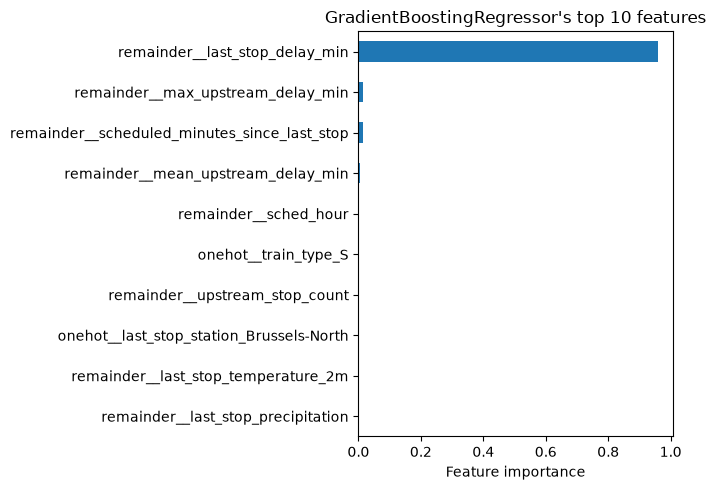

In [8]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(
    model.named_steps["regressor"].feature_importances_, index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
importances.head(10).iloc[::-1].plot.barh(ax=ax)
ax.set_xlabel("Feature importance")
ax.set_title("GradientBoostingRegressor's top 10 features")
plt.tight_layout()

importances.head(10)


`last_stop_delay_min` alone accounts for the vast majority of the model's importance! Everything else (upstream trend, schedule, weather, train type) is a rounding error by comparison. That's a clean, honest story for Stage 5: **delay propagation is the whole game here**, and a fancier model doesn't change that story, it just squeezes a little more precision out of it.

## Wrapping Up

**Caveat for Stage 5, restated:** this model predicts Leuven's arrival delay from whatever lead time `scheduled_minutes_since_last_stop` actually gives us for a given run, where median about 8 minutes, not the full hour the original business framing asks for. That's a real limitation of what these 6 corridor stations can support, not a modeling choice, and it should be part of how Stage 5 frames "1-hour-ahead" performance to stakeholders.

We save predictions from both the best baseline (`persistence`) and the model, on `val` and `test`, for Stage 5's evaluation and storytelling work.

In [9]:
def build_predictions(df, split_name):
    out = df[["TRAIN_NO", "service_date", "RELATION", "sched_hour", "sched_dow", "train_type"]].copy()
    out["split"] = split_name
    out[TARGET_COL] = df[TARGET_COL].to_numpy()
    out["baseline_pred"] = predict_persistence(df)
    out["model_pred"] = model.predict(df[FEATURE_COLS])
    return out

predictions = pd.concat(
    [build_predictions(val, "val"), build_predictions(test, "test")], ignore_index=True
)

os.makedirs("../data/checkpoints", exist_ok=True)
predictions.to_csv(PREDICTIONS_PATH, index=False)

check = pd.read_csv(PREDICTIONS_PATH)
print(check.shape)
check.head()


(14759, 10)


,TRAIN_NO,service_date,RELATION,sched_hour,sched_dow,train_type,split,delay_arr_min,baseline_pred,model_pred
0,11,2026-05-01,ICE,6,Friday,ICE,val,2.116667,0.233333,0.223755
1,11,2026-05-02,ICE,6,Saturday,ICE,val,12.583333,8.833333,11.348417
2,11,2026-05-03,ICE,6,Sunday,ICE,val,1.283333,-0.133333,-0.062640
3,11,2026-05-04,ICE,6,Monday,ICE,val,1.233333,0.583333,0.792924
4,11,2026-05-05,ICE,6,Tuesday,ICE,val,1.166667,0.950000,1.038780
